# BioReason-Pro SFT term-prediction assessments on ARGO95

This notebook checks the per-term prediction assessments stored in
`genes/<species>/<gene>/<gene>-sft-predictions.yaml`. Each predicted GO term
carries a `review.assessment` using the Expert Synthetic Review taxonomy
(COR / CNN / LSP / UNC / PLI / NPI / REP), the same scheme used in
`ESR-ECOLI-DET-Mini` and in the SFT results of the manuscript.

The primary SFT term benchmark is **ARGO95**, the 95-gene ARGO139 subset with
HuggingFace `wanglab/protein_catalogue` SFT GO-term predictions. ARGO139 remains
the 139-gene RL narrative benchmark. The 44 ARGO139 genes absent from the HF
catalogue have BioReason-Pro SFT web exports, but those exports expose a much
larger ancestor-rich GO-term panel and are retained only as a supplemental
source-diagnostic view. The all-source SFT union (ARGO139 plus HF-only genes)
is also retained as a supplemental availability view. The cohort membership is enumerated in
`projects/BIOREASON_COMPARISON/benchmark-cohorts.csv` and
`projects/BIOREASON_COMPARISON/benchmark-genes.csv`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import bioreason_stats as bs

ROOT = bs.find_repo_root()
preds = bs.load_prediction_assessments(ROOT)
rl_keys = bs.load_rl_benchmark_keys(ROOT)
preds["benchmark_key"] = list(zip(preds.species, preds.gene))
preds["in_rl_benchmark"] = preds["benchmark_key"].isin(rl_keys)
n_genes = preds[["species", "gene"]].drop_duplicates().shape[0]
print(f"genes with prediction files: {n_genes}")
print(f"total predicted terms:       {len(preds)}")
print(f"ARGO139 genes:               {len(rl_keys)}")
print("\nsource methods:")
print(preds.source_method.value_counts().to_string())
print("\nsource versions:")
print(preds.source_version.value_counts().to_string())
preds.head()

genes with prediction files: 198
total predicted terms:       11100
ARGO139 genes:               139

source methods:
source_method
BioReason-Pro-SFT    11100

source versions:
source_version
app.bioreason.net/SFT        9742
wanglab/protein_catalogue    1358


,species,gene,source_method,source_version,term_id,term_label,term_type,assessment,confidence_score,path,benchmark_key,in_rl_benchmark
0,9CAUD,dfrP,BioReason-Pro-SFT,app.bioreason.net/SFT,GO:0003824,catalytic activity,GO_MF,LSP,2,genes/9CAUD/dfrP/dfrP-sft-predictions.yaml,"(9CAUD, dfrP)",True
1,9CAUD,dfrP,BioReason-Pro-SFT,app.bioreason.net/SFT,GO:0016491,oxidoreductase activity,GO_MF,CNN,2,genes/9CAUD/dfrP/dfrP-sft-predictions.yaml,"(9CAUD, dfrP)",True
2,9CAUD,dfrP,BioReason-Pro-SFT,app.bioreason.net/SFT,GO:0016645,acting on the CH-NH group of donors,GO_MF,LSP,2,genes/9CAUD/dfrP/dfrP-sft-predictions.yaml,"(9CAUD, dfrP)",True
3,9CAUD,dfrP,BioReason-Pro-SFT,app.bioreason.net/SFT,GO:0016646,NAD or NADP as acceptor,GO_MF,CNN,2,genes/9CAUD/dfrP/dfrP-sft-predictions.yaml,"(9CAUD, dfrP)",True
4,9CAUD,dfrP,BioReason-Pro-SFT,app.bioreason.net/SFT,GO:0004146,dihydrofolate reductase activity,GO_MF,CNN,2,genes/9CAUD/dfrP/dfrP-sft-predictions.yaml,"(9CAUD, dfrP)",True


## Primary SFT benchmark: ARGO95

This is the main denominator for SFT term review. ARGO95 is the HF-catalogue subset nested inside the ARGO139 RL narrative benchmark.

In [2]:
primary = preds[preds.in_rl_benchmark].copy()
primary_hf = primary[primary.source_version == "wanglab/protein_catalogue"].copy()
primary_web = primary[primary.source_version != "wanglab/protein_catalogue"].copy()
argo95 = primary_hf.copy()

print("ARGO95 primary SFT benchmark:")
print(f"  genes: {argo95[['species', 'gene']].drop_duplicates().shape[0]}")
print(f"  terms: {len(argo95)}")
print("\nSupplemental mixed-source ARGO139 diagnostic:")
print(f"  genes: {primary[['species', 'gene']].drop_duplicates().shape[0]}")
print(f"  terms: {len(primary)}")
print(f"  HF genes: {primary_hf[['species', 'gene']].drop_duplicates().shape[0]} "
      f"({len(primary_hf)} terms)")
print(f"  web-export genes: {primary_web[['species', 'gene']].drop_duplicates().shape[0]} "
      f"({len(primary_web)} terms)")
print("\nCoverage check:")
hf_gene_keys = set(zip(primary_hf.species, primary_hf.gene))
web_gene_keys = set(zip(primary_web.species, primary_web.gene))
print(f"  ARGO139 genes with HF SFT terms: {len(hf_gene_keys)}")
print(f"  ARGO139 genes absent from HF, diagnostic web export only: {len(web_gene_keys)}")
print(f"  web set equals ARGO139 minus HF: {web_gene_keys == (rl_keys - hf_gene_keys)}")

ARGO95 primary SFT benchmark:
  genes: 95
  terms: 955

Supplemental mixed-source ARGO139 diagnostic:
  genes: 139
  terms: 10697
  HF genes: 95 (955 terms)
  web-export genes: 44 (9742 terms)

Coverage check:
  ARGO139 genes with HF SFT terms: 95
  ARGO139 genes absent from HF, diagnostic web export only: 44
  web set equals ARGO139 minus HF: True


## Assessment Distribution

Ordered by the Expert Synthetic Review taxonomy, with glosses. The first table is ARGO95. The mixed-source ARGO139 and web-export tables are diagnostic because the web export includes many ancestor terms.

In [3]:
def assessment_table(frame):
    counts = frame.assessment.value_counts()
    order = [a for a in bs.ASSESSMENT_ORDER if a in counts.index]
    order += [a for a in counts.index if a not in bs.ASSESSMENT_ORDER]  # any extras
    table = pd.DataFrame({
        "count": [counts[a] for a in order],
        "pct": [round(100 * counts[a] / len(frame), 1) for a in order],
        "meaning": [bs.ASSESSMENT_GLOSS.get(a, "?") for a in order],
    }, index=order)
    table.index.name = None
    return table

def print_distribution(label, frame):
    table = assessment_table(frame)
    genes = frame[["species", "gene"]].drop_duplicates().shape[0]
    print(f"\n{label} ({genes} genes, {len(frame)} terms):")
    print(table.to_string())
    non_unc = frame[frame.assessment != "UNC"].copy()
    print(f"non-UNC: {len(non_unc)} / {len(frame)} ({100 * len(non_unc) / len(frame):.1f}%)")
    if len(non_unc):
        print("non-UNC distribution:")
        print(assessment_table(non_unc).to_string())
    return table

argo95_table = print_distribution("ARGO95 SFT benchmark, HF catalogue source", argo95)
primary_table = print_distribution("Supplemental mixed-source ARGO139", primary)
primary_web_table = print_distribution("ARGO139, web-export source", primary_web)


ARGO95 SFT benchmark, HF catalogue source (95 genes, 955 terms):
     count   pct                                                     meaning
COR     24   2.5                                               Correct novel
CNN    678  71.0  Correct but Not Novel (established annotation or evidence)
LSP     44   4.6                       Less Precise than existing annotation
UNC     57   6.0                       Uncertain - cannot validate or refute
PLI      5   0.5                                           Paralog Incorrect
NPI    118  12.4                              Nonparalog Incorrect (refuted)
REP     29   3.0                                 Repetition / frequency bias
non-UNC: 898 / 955 (94.0%)
non-UNC distribution:
     count   pct                                                     meaning
COR     24   2.7                                               Correct novel
CNN    678  75.5  Correct but Not Novel (established annotation or evidence)
LSP     44   4.9                      

## Terms per gene

This shows why the source label matters: HF catalogue entries are leaf-ish, while web-export entries include much of the ancestor hierarchy.

In [4]:
for label, frame in [
    ("ARGO95, HF source", argo95),
    ("ARGO139, web-export source", primary_web),
    ("Supplemental mixed-source ARGO139", primary),
]:
    per_gene = frame.groupby(["species", "gene"]).size().rename("n_terms")
    print("\n" + label)
    print(per_gene.describe().round(1).to_string())


ARGO95, HF source
count    95.0
mean     10.1
std       6.9
min       3.0
25%       5.0
50%       7.0
75%      13.0
max      38.0

ARGO139, web-export source
count     44.0
mean     221.4
std      170.1
min        7.0
25%       54.5
50%      212.5
75%      332.5
max      598.0

Supplemental mixed-source ARGO139
count    139.0
mean      77.0
std      137.1
min        3.0
25%        6.0
50%       12.0
75%       39.0
max      598.0


## Supplemental Views

These retain the availability-driven denominators for reproducibility: all current SFT genes, and the full HF catalogue subset.

In [5]:
hf = preds[preds.source_version == "wanglab/protein_catalogue"].copy()
web = preds[preds.source_version != "wanglab/protein_catalogue"].copy()
hf_only = hf[~hf.in_rl_benchmark].copy()

print_distribution("Supplemental all-source union, all SFT predictions", preds)
print_distribution("Supplemental HF catalogue subset, all current genes", hf)
print(f"\nHF-only genes outside ARGO139: "
      f"{hf_only[['species', 'gene']].drop_duplicates().shape[0]} "
      f"({len(hf_only)} terms)")


Supplemental all-source union, all SFT predictions (198 genes, 11100 terms):
     count   pct                                                     meaning
COR     38   0.3                                               Correct novel
CNN   3238  29.2  Correct but Not Novel (established annotation or evidence)
LSP    445   4.0                       Less Precise than existing annotation
UNC   7126  64.2                       Uncertain - cannot validate or refute
PLI      5   0.0                                           Paralog Incorrect
NPI    214   1.9                              Nonparalog Incorrect (refuted)
REP     34   0.3                                 Repetition / frequency bias
non-UNC: 3974 / 11100 (35.8%)
non-UNC distribution:
     count   pct                                                     meaning
COR     38   1.0                                               Correct novel
CNN   3238  81.5  Correct but Not Novel (established annotation or evidence)
LSP    445  11.2       

saved figures/assessment_distribution.repro.png
saved ../article/figures/sft_assessment_distribution.png


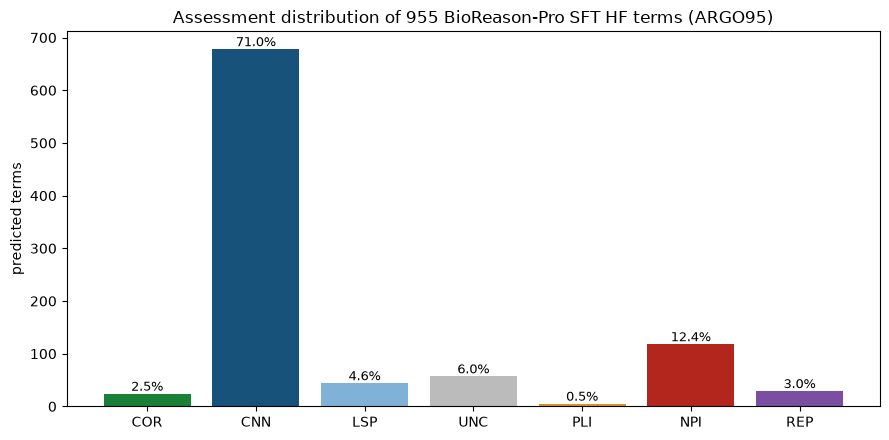

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {"COR": "#1a7f37", "CNN": "#16527a", "LSP": "#7fb2d6",
          "UNC": "#bbbbbb", "PLI": "#e0902a", "NPI": "#b3261e", "REP": "#7a4ea3"}
ax.bar(argo95_table.index, argo95_table["count"],
       color=[colors.get(a, "#888") for a in argo95_table.index])
for i, (a, row) in enumerate(argo95_table.iterrows()):
    ax.text(i, row["count"], f"{row['pct']}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("predicted terms")
ax.set_title(f"Assessment distribution of {len(primary_hf)} BioReason-Pro SFT HF terms "
             f"(ARGO95)")
fig.tight_layout()
outdir = Path("figures"); outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "assessment_distribution.repro.png", dpi=120)
paper_outdir = Path("../article/figures"); paper_outdir.mkdir(parents=True, exist_ok=True)
fig.savefig(paper_outdir / "sft_assessment_distribution.png", dpi=180)
print("saved", outdir / "assessment_distribution.repro.png")
print("saved", paper_outdir / "sft_assessment_distribution.png")
plt.show()

### Interpreting the result

The primary SFT denominator is ARGO95. The mixed-source ARGO139 and web-export
views should be read as diagnostics because the web export includes the full GO
ancestor hierarchy. The all-source union and all-HF catalogue views are retained
as supplemental review views, not as primary BioReason-Pro benchmarks.